In [22]:
# !pip install pandas plotly matplotlib seaborn nbformat scikit-learn  pyarrow==14.0.2 --upgrade --quiet

In [23]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn import preprocessing
from urllib.request import urlretrieve
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
%matplotlib inline

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize']=(10,6)
matplotlib.rcParams['figure.facecolor']='#00000000'

**Reading values from Parquet**

In [24]:
train_inputs=pd.read_parquet('train_inputs.parquet')
val_inputs=pd.read_parquet('val_inputs.parquet')
test_inputs=pd.read_parquet('test_inputs.parquet')

X_train=pd.read_parquet('X_train.parquet')
X_val=pd.read_parquet('X_val.parquet')
X_test=pd.read_parquet('X_test.parquet')

train_targets=pd.read_parquet('train_targets.parquet')['RainTomorrow']
val_targets=pd.read_parquet('val_targets.parquet')['RainTomorrow']
test_targets=pd.read_parquet('test_targets.parquet')['RainTomorrow']

In [25]:
print('train_inputs: ',train_inputs.shape)
print('train_targets: ',train_targets.shape)
print('X_train: ',X_train.shape)
print('val_inputs: ',val_inputs.shape)
print('val_targets: ',val_targets.shape)
print('X_val: ',X_val.shape)
print('test_inputs: ',test_inputs.shape)
print('test_targets: ',test_targets.shape)
print('Xtest.shape: ',X_test.shape)

train_inputs:  (98988, 124)
train_targets:  (98988,)
X_train:  (98988, 119)
val_inputs:  (17231, 124)
val_targets:  (17231,)
X_val:  (17231, 119)
test_inputs:  (25974, 124)
test_targets:  (25974,)
Xtest.shape:  (25974, 119)


**Training and Visualization of Random Forest**

In [26]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_jobs=-1,random_state=42).fit(X_train,train_targets)

In [27]:
print('Acc for training',model.score(X_train,train_targets))
print('Acc for validation',model.score(X_val,val_targets))
print('Acc for testing',model.score(X_test,test_targets))

Acc for training 0.9999494888269285
Acc for validation 0.8566537055307295
Acc for testing 0.8447678447678447


In [28]:
train_proba=model.predict_proba(X_train)
train_proba

array([[0.93, 0.07],
       [1.  , 0.  ],
       [0.99, 0.01],
       ...,
       [0.99, 0.01],
       [1.  , 0.  ],
       [0.96, 0.04]], shape=(98988, 2))

In [29]:
len(model.estimators_)#number of binary trees

100

In [30]:
model.estimators_[0]

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,1608637542
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.875, 'Sunshine <= 0.403\ngini = 0.347\nsamples = 62607\nvalue = [76887, 22101]'),
 Text(0.25, 0.625, 'Pressure9am <= 0.609\ngini = 0.499\nsamples = 11288\nvalue = [9272, 8542]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Cloud9am <= 0.833\ngini = 0.475\nsamples = 6067\nvalue = [3702, 5808]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'WindGustDir_NNE <= 0.5\ngini = 0.442\nsamples = 5221\nvalue = [5570.0, 2734.0]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'RainToday_Yes <= 0.5\ngini = 0.278\nsamples = 51319\nvalue = [67615, 13559]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Pressure9am <= 0.521\ngini = 0.207\nsamples = 41960\nvalue = [58514.0, 7796.0]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Pressure9am <= 0.614\ngini = 0.475\nsamples = 9359\nvalue = [9101, 5763]'),
 Text(0.8125, 0.1

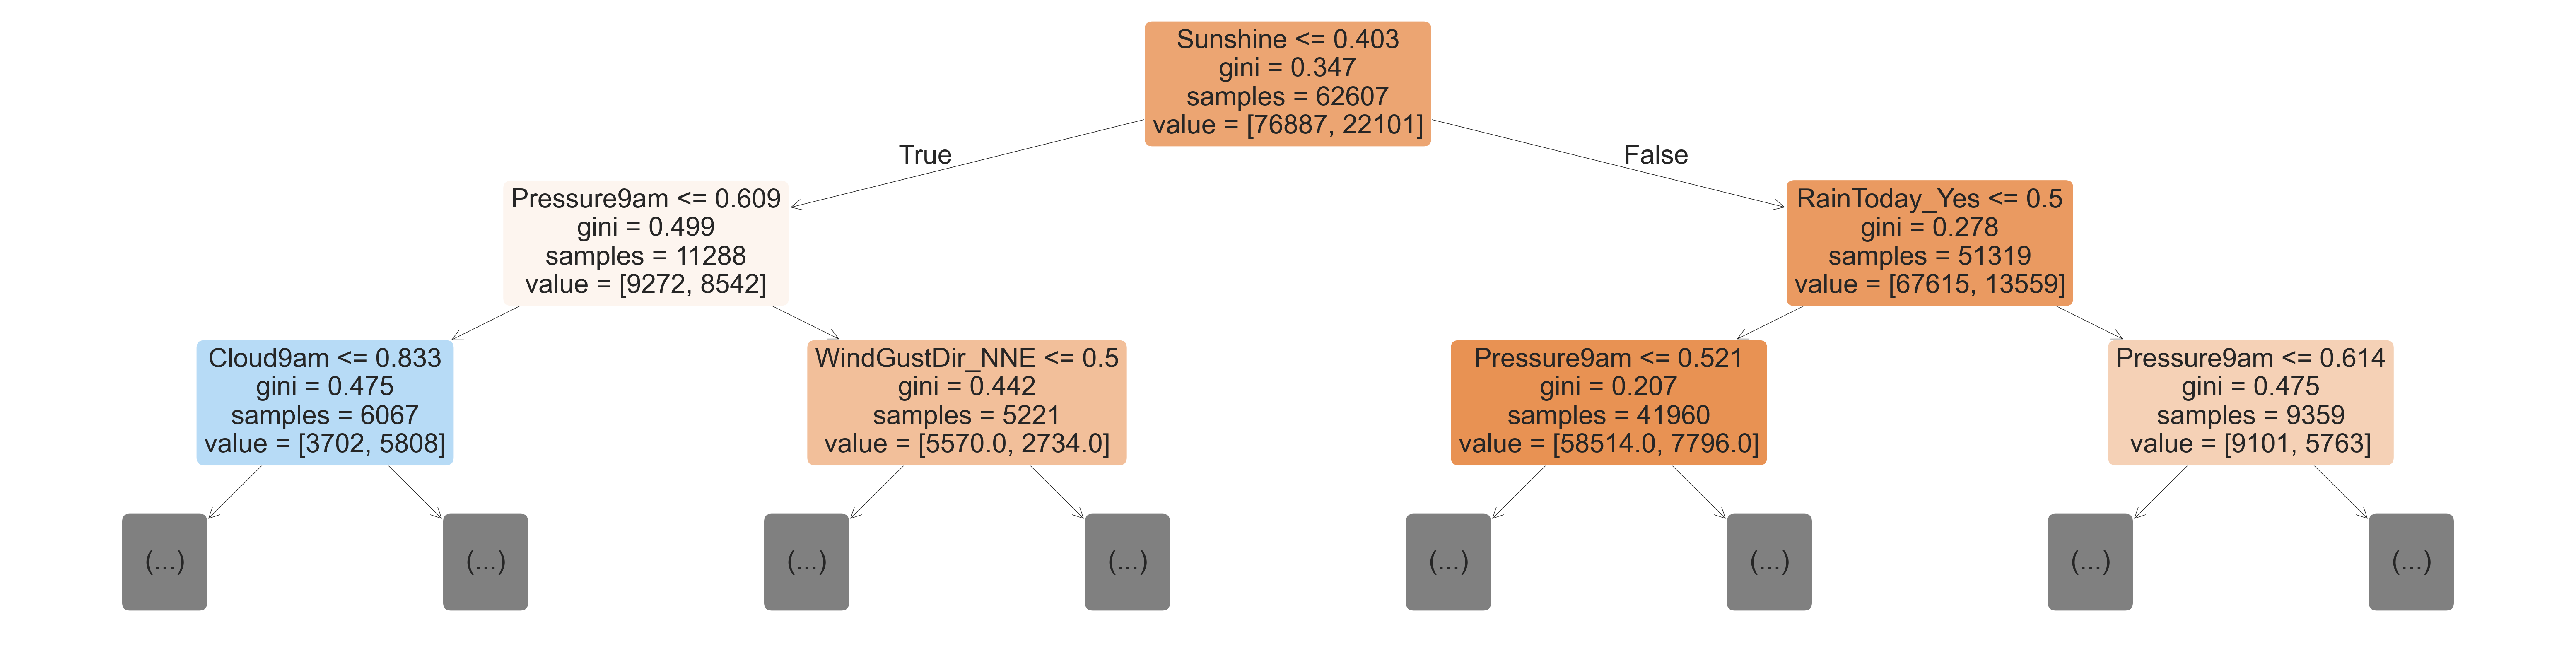

In [31]:
from sklearn.tree import plot_tree,export_text
plt.figure(figsize=(80,20))
plot_tree(model.estimators_[0],max_depth=2,feature_names=X_train.columns,filled=True,rounded=True)

[Text(0.5, 0.875, 'RainToday_Yes <= 0.5\ngini = 0.349\nsamples = 62610\nvalue = [76714, 22274]'),
 Text(0.25, 0.625, 'WindGustDir_ESE <= 0.5\ngini = 0.262\nsamples = 48715\nvalue = [65024, 11930]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Pressure3pm <= 0.505\ngini = 0.267\nsamples = 46043\nvalue = [61211.0, 11515.0]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Humidity3pm <= 0.665\ngini = 0.177\nsamples = 2672\nvalue = [3813, 415]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'WindSpeed3pm <= 0.333\ngini = 0.498\nsamples = 13895\nvalue = [11690, 10344]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Sunshine <= 0.534\ngini = 0.495\nsamples = 11567\nvalue = [10070, 8283]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Sunshine <= 0.424\ngini = 0.493\nsamples = 2328\nvalue = [1620, 2061]'),
 Text(0.8125, 0.

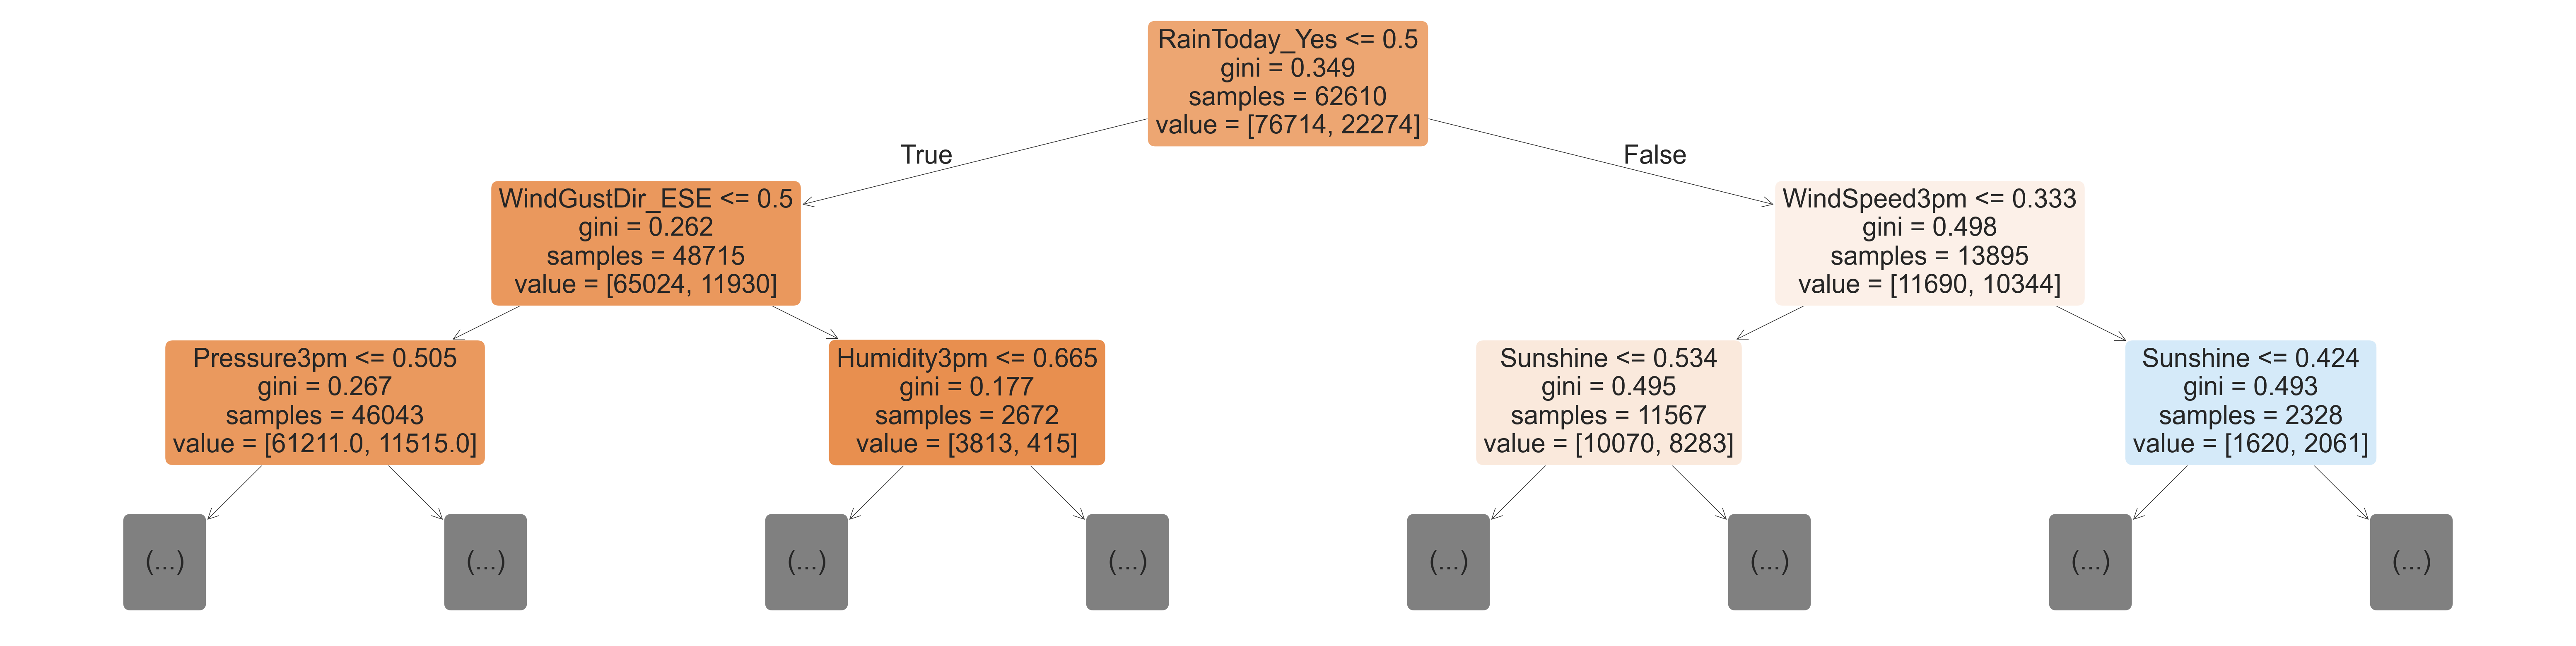

In [32]:
from sklearn.tree import plot_tree,export_text
plt.figure(figsize=(80,20))
plot_tree(model.estimators_[20],max_depth=2,feature_names=X_train.columns,filled=True,rounded=True)

**Limiting n estimators in model**

In [39]:
NEst_model=RandomForestClassifier(random_state=42,n_jobs=-1,n_estimators=500).fit(X_train,train_targets)

In [40]:
print('Acc for training',NEst_model.score(X_train,train_targets))
print('Acc for validation',NEst_model.score(X_val,val_targets))
print('Acc for testing',NEst_model.score(X_test,test_targets))

Acc for training 0.9999797955307714
Acc for validation 0.8577563693343393
Acc for testing 0.8463463463463463


**Limiting n estimators in model**

In [68]:
MD_model=RandomForestClassifier(random_state=42,n_jobs=-1,max_depth=26).fit(X_train,train_targets)

In [69]:
print('Acc for training',MD_model.score(X_train,train_targets))
print('Acc for validation',MD_model.score(X_val,val_targets))
print('Acc for testing',MD_model.score(X_test,test_targets))

Acc for training 0.9814826039519942
Acc for validation 0.8572340549010504
Acc for testing 0.8456148456148456
